# Test-Szenario A1
Wie gut können LLMs Feebdack zu den gegebenen Antworten geben?
_Könnte **Test-Szenarien S7, S8, S9** abdecken_

_Anwendbar auch für Test-Szenarien 3 und 4_
- _**Test-Szenario A3**: Evaluierung von verbesserten Spracheingaben -> wie oft wird das Gesprochene wie erwartet bewertet?_
- _**Test-Szenario A4**: Evaluierung von invarianten Spracheingaben -> wie oft, trotz Fehlern in der Eingabe, wird das Gesprochene wie erwartet bewertet? (deckt **Test-Szenario S3** ab)_
- _**Test-Szenario S2**: Erfolgt eine Ergänzungs-/Rückfrage wie erwartet?_

## Load Input Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dir_path = Path(".")  # current directory
keep_cols = ["question_de", "answer_de", "max_points", "keywords", "student_answer", "human_score", "human_feedback", "rueckfrage",
             "error_type"]

dfs = []
for fp in sorted(dir_path.glob("*.tsv")):
    df_tmp = pd.read_csv(fp, sep="\t", dtype=str)
    df_tmp = df_tmp.reindex(columns=keep_cols)  # keeps order, fills missing with NA
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)  # appends; duplicates are kept
df["max_points"] = df["max_points"].str.replace(",", ".").astype(float)
df["human_score"] = df["human_score"].str.replace(",", ".").astype(float)
df["error_type"] = df["error_type"].astype(int)
df["rueckfrage"] = df["rueckfrage"].astype(int)

# check for column names: question_text, student_answer, gold_answer, maximal_score, human_score, human_feedback
df.head()

,question_de,answer_de,max_points,keywords,student_answer,human_score,human_feedback,rueckfrage,error_type
0,Was ist der Zweck von t-Tests in der EDA?,"T-Tests in der EDA werden verwendet, um die Mi...",6.0,t-Tests; unabhängige Stichproben; bekannter We...,EDA steht für Explorative Datenanalyse. T-Test...,6.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
1,Was ist der Zweck nicht-parametrischer Tests i...,Nicht-parametrische Tests in der EDA werden ve...,4.0,nicht-parametrische Tests; EDA; Annahmen param...,Nicht-parametrische Tests in der EDA werden ve...,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
2,Was ist der Zweck der explorativen Faktorenana...,Die explorative Faktorenanalyse (EFA) im Rahme...,4.0,explorative Faktorenanalyse; EDA; zugrunde lie...,"Der Zweck besteht darin, die Ursache oder aber...",4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
3,Was ist der Unterschied zwischen EFA und Haupt...,EFA und PCA sind beide Verfahren zur Reduktion...,6.0,EFA; PCA; Dimensionality Reduction; explorativ...,"Da ich nicht weiß, wofür EFA steht, kann ich l...",0.0,1) Die gegebene Antwort lässt keinen Rückschlu...,3,2
4,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm in der hierarchischen Clustera...,6.0,Dendrogramm; hierarchische Beziehungen; Mergin...,Ein Dendrogramm hilft in der hierarchischen Cl...,2.5,1) Die Antwort wurde fachlich korrekt dargeste...,2,2


In [2]:
len(df)

95

## Call LLMs

In [3]:
from llm_handler import LLMHandler
import json

# TODO: Write prompt for evaluation
prompt = """
Du bekommst eine Prüfungsfrage, die Antwort eines Studenten darauf, die Musterlösung zu der Frage und die maximal erreichbare Punktzahl für eine richtige Antwort.
Deine Aufgabe ist es, die Antwort des Studenten mit der Musterlösung zu vergleichen und diese zu bewerten.

Dabei sollst du dich an folgendem Leitfaden orientieren:
1) Hat der Student den Sachverhalt fachlich korrekt dargestellt, ohne wesentliche Fehler oder falsche Zusammenhänge?
2) Verwendet der Student die relevanten Schlüsselbegriffe korrekt und im richtigen Kontext? Schau dabei auf folgende Liste der wichtigsten Fachbegriffe: {keywords}.
3) Geht der Student auf alle wesentlichen Aspekte der Fragestellung ein oder bleiben zentrale Punkte unbeantwortet?
4) Werden die angesprochenen Konzepte klar voneinander unterschieden und nicht miteinander vermischt?
5) Ist die Antwort logisch aufgebaut, nachvollziehbar formuliert und für den Prüfer gut verständlich?
6) Soll vom Prüfer eine Rückfrage gestellt werden, um auf Lücken zu prüfen?

Deine Ausgabe soll aus folgenden Elementen bestehen:
- **llm_feedback**: In diesem Feld schreibst du die Bewertung zur Antwort des Studenten. Dabei gehst du auf jeden der oben genannten Punkte ein und formulierst anschließend einen Fließtext daraus. Beschränke dich bei dem Fließtext auf maximal 4-5 Sätze.
- **llm_rating**: Hier vergibst du die Punktzahl, die deiner Meinung nach die Antwort des Studenten wiederspiegelt. Du kannst die Punkte in 0,5 Schritten vergeben. Die maximal vergebbare Punktzahl ist {max_score}.
- **rueckfrage**: Du füllst dieses Feld mit einem Integer aus. Dieser Integer kann 0, 1, 2 oder 3 sein. 0 bedeutet, dass keine Rückfrage notwendig ist. 1 bedeutet, dass eine Rückfrage notwendig ist, die sich auf nicht genannte Fach- bzw. Schlüsselbegriffe bezieht. 2 bedeutet, dass eine Rückfrage gestellt wird und sich auf eine fehlende Teilantwort bezieht. 3 bedeutet, dass sich die gestellte Rückfrage auf einem Teil der falschen Antwort bezieht.

Frage:
{question}

Studentenantwort:
{student_answer}

Musterlösung:
{correct_answer}

Für diese Frage gibt es maximal {max_score} Punkte.

<Antwortformat>
```json
{{
"llm_feedback": "<Hier antwortest du auf die Antwort des Studenten und gibts ihm Feedback entsprechend der Analysepunkte. Die Antwort ist ein Text, es gibt keine JSON-Struktur>",
"llm_rating": "<Gesamtrating, maximale Punkte: {max_score}, gerundet auf eine Nachkommastelle>",
"rueckfrage": "<0 | 1 | 2 | 3>"
}}```
"""

In [4]:
import time

def _results_current_model(llm: LLMHandler, prompt: str, df: pd.DataFrame) -> pd.DataFrame:
  llm_results = []
  for _, row in df.iterrows():
    prompt_filled = prompt.format(
      question=row['question_de'],
      student_answer=row['student_answer'],
      keywords=row["keywords"],
      correct_answer=row['answer_de'],
      max_score=row['max_points']
    )
    while True:
      try:
        print(f"Try processing row {_}")
        answer = llm.call_llm(prompt=prompt_filled)
        if not isinstance(answer, dict):
          raise ValueError("LLM response is not a dictionary")
        answer["question"] = row['question_de']
        answer["student_answer"] = row['student_answer']
        answer["correct_answer"] = row['answer_de']
        answer["keywords"] = row["keywords"]
        answer["max_score"] = row['max_points']
        answer["human_score"] = row['human_score']
        answer["human_feedback"] = row['human_feedback']
        answer["rueckfrage_human"] = row["rueckfrage"]
        llm_results.append(answer)
        with open("checkpoint.json", "a", encoding="utf-8") as f:
          f.write(json.dumps(answer, ensure_ascii=False) + "\n")
        break
      except Exception as e:
        print(f"Row {_}: retrying due to error: {e}")
        time.sleep(10)
  return pd.DataFrame(llm_results)

In [ ]:
# models = ["gemma3:27b", "gemma3:4b", "deepseek-r1:8b", "llama3.1:latest", "command-r7b:latest", "mixtral:latest",
#          "mistral-small3.1:latest", "llama3.3:latest", "phi4:latest"]

# for testing purposes
models = ["llama3.1:latest", "command-r7b:latest", "mixtral:latest", "phi4:latest"]

dfs = []

for model in models:
  llm_handler = LLMHandler(model=model)

  df_model = _results_current_model(llm_handler, prompt, df)
  df_model["model"] = model
  dfs.append(df_model)
  
final_df = pd.concat(dfs, ignore_index=True)

Try processing row 0
Row 0: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 0
Row 0: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 0
Row 0: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 0
Try processing row 1
Row 1: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 1
Row 1: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 1
Try processing row 2
Try processing row 3
Row 3: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 3
Row 3: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 3
Row 3: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 3
Row 3: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try processing row 3
Row 3: retrying due to error: Expecting value: line 1 column 1 (char 0)
Try pro

In [6]:
final_df.to_csv("llm_evaluation_results_normal_second_try.csv", index=False)

## Evaluate LLM Answers

### Semantic Similarity of LLM Feedback with Human Feedback

In [27]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import torch

device = torch.device("cpu")

final_df = pd.read_csv("llm_evaluation_combined_normal.csv")

semantic_judge = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def _semantic_similarity(a: str, b: str) -> float:
  """Calculate the semantic similarity between two texts using cosine similarity of their embeddings.

  Args:
      a (str): The first text to compare.
      b (str): The second text to compare.

  Returns:
      float: A float value between -1 and 1 indicating the semantic similarity between the two texts.
  """
  emb_a = semantic_judge.encode(a, convert_to_tensor=True).detach().cpu()
  emb_b = semantic_judge.encode(b, convert_to_tensor=True).detach().cpu()

  sim = cosine_similarity(emb_a.reshape(1, -1).numpy(), emb_b.reshape(1, -1).numpy())[0][0]
  
  return float(sim)

In [28]:
final_df

,Unnamed: 0.1,Unnamed: 0,question,answer,llm_feedback,llm_rating,rueckfrage,student_answer,correct_answer,keywords,max_score,human_score,human_feedback,rueckfrage_human,model
0,0,152.0,Was ist der Zweck von t-Tests in der EDA?,"T-Tests in der EDA werden verwendet, um die Mi...",Die Antwort des Studenten ist im Wesentlichen ...,5.5,0.0,EDA steht für Explorative Datenanalyse. T-Test...,"T-Tests in der EDA werden verwendet, um die Mi...",t-Tests; unabhängige Stichproben; bekannter We...,6.0,6.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,gemma3:27b
1,1,154.0,Was ist der Zweck nicht-parametrischer Tests i...,Nicht-parametrische Tests in der EDA werden ve...,Die Antwort des Studenten ist im Wesentlichen ...,3.5,1.0,Nicht-parametrische Tests in der EDA werden ve...,Nicht-parametrische Tests in der EDA werden ve...,nicht-parametrische Tests; EDA; Annahmen param...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,gemma3:27b
2,2,156.0,Was ist der Zweck der explorativen Faktorenana...,Die explorative Faktorenanalyse (EFA) im Rahme...,Die Antwort des Studenten ist im Wesentlichen ...,3.5,1.0,"Der Zweck besteht darin, die Ursache oder aber...",Die explorative Faktorenanalyse (EFA) im Rahme...,explorative Faktorenanalyse; EDA; zugrunde lie...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,gemma3:27b
3,3,157.0,Was ist der Unterschied zwischen EFA und Haupt...,EFA und PCA sind beide Verfahren zur Reduktion...,Die Antwort des Studenten ist leider nicht aus...,0.0,1.0,"Da ich nicht weiß, wofür EFA steht, kann ich l...",EFA und PCA sind beide Verfahren zur Reduktion...,EFA; PCA; Dimensionality Reduction; explorativ...,6.0,0.0,1) Die gegebene Antwort lässt keinen Rückschlu...,3.0,gemma3:27b
4,4,161.0,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm in der hierarchischen Clustera...,Die Antwort des Studenten ist grundsätzlich ko...,5.0,1.0,Ein Dendrogramm hilft in der hierarchischen Cl...,Ein Dendrogramm in der hierarchischen Clustera...,Dendrogramm; hierarchische Beziehungen; Mergin...,6.0,2.5,1) Die Antwort wurde fachlich korrekt dargeste...,2.0,gemma3:27b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,850,54.0,Was ist der Zweck von A/B-Tests im Data Science?,"A/B-Testing wird verwendet, um zwei oder mehr ...",Die Antwort des Studenten hat den Sachverhalt ...,6.0,0.0,A/B-Tests ermöglichen einen Vergleich zwischen...,"A/B-Testing wird verwendet, um zwei oder mehr ...",A/B-Testing; Produkte oder Interventionen; vor...,6.0,6.0,Die Antwort stellt den Zweck von A/B-Tests fac...,0.0,phi4:latest
851,851,57.0,Was ist der Unterschied zwischen Klassifikatio...,Klassifikation ist eine überwachte Lernaufgabe...,Die Antwort des Studenten stellt den Sachverha...,5.0,0.0,Bei der Klassifikation handelt es sich um eine...,Klassifikation ist eine überwachte Lernaufgabe...,Klassifikation; überwachte Lernens; Klassen vo...,5.0,5.0,Die Antwort stellt sowohl Klassifikation als a...,0.0,phi4:latest
852,852,59.0,Welche Rolle spielt Regularisierung in neurona...,"Regularisierung in neuronalen Netzen hilft, Üb...",Die Antwort des Studenten beschreibt fachlich ...,6.0,0.0,"Regularisierung verringert Überanpassung, inde...","Regularisierung in neuronalen Netzen hilft, Üb...",Regularisierung; neuronale Netze; Überanpassun...,6.0,5.5,Die Antwort beschreibt die Rolle der Regularis...,0.0,phi4:latest
853,853,49.0,Welche Rolle spielt die Regularisierung bei de...,Regularisierung in Machine Learning reduziert ...,Der Student hat den Sachverhalt fachlich korre...,3.5,2.0,Regularisierung fördert Modelle mit kleineren ...,Regularisierung in Machine Learning reduziert ...,Regularisierung; Modellkomplexität; Strafterme...,6.0,4.5,1) Die Teilantwort wurde fachlich korrekt darg...,2.0,phi4:latest


In [29]:
import re
import pandas as pd

from sacrebleu.metrics import CHRF

# --- BERTScore ---
from bert_score import score as bertscore_score

# --- Keyphrase extraction (LLM-frei) ---
import yake


# =============== chrF ===============
_chrf = CHRF(word_order=2)  # Standard: chrF++; gut für Deutsch/Paraphrasen

def chrf_score(pred: str, ref: str) -> float:
    pred = "" if pred is None else str(pred)
    ref  = "" if ref  is None else str(ref)
    # sacrebleu expects list of hypotheses and list-of-list references
    return float(_chrf.corpus_score([pred], [[ref]]).score / 100.0)  # 0..1


# =============== Sentence splitting (Deutsch) ===============
# Optional: spaCy, falls verfügbar (besser als Regex)
try:
    import spacy
    _nlp = spacy.load("de_core_news_sm")
    def split_sentences_de(text: str):
        text = "" if text is None else str(text).strip()
        if not text:
            return []
        doc = _nlp(text)
        return [s.text.strip() for s in doc.sents if s.text.strip()]
except Exception:
    _nlp = None
    def split_sentences_de(text: str):
        text = "" if text is None else str(text).strip()
        if not text:
            return []
        # einfache Heuristik: split nach . ! ? oder Zeilenumbrüchen
        parts = re.split(r"(?<=[\.\!\?])\s+|\n+", text)
        return [p.strip() for p in parts if p.strip()]


# =============== Error-Content-F1 ===============
# 1) "kritische" Sätze filtern (Fehler/Fehlendes/Unklarheit)
ERROR_CUES = [
    "falsch", "fehler", "fehlt", "fehlend", "unklar", "verwechselt", "widerspricht",
    "stimmt nicht", "nicht korrekt", "nicht richtig", "irreführ", "unvollständig",
    "kein", "nicht", "ohne", "aber", "jedoch"
]

def select_error_sentences(text: str):
    sents = split_sentences_de(text)
    out = []
    for s in sents:
        low = s.lower()
        if any(cue in low for cue in ERROR_CUES):
            out.append(s)
    # Falls nichts gefunden wurde: nimm den ganzen Text (damit F1 nicht immer 0 wird)
    if not out and text:
        out = [text]
    return out

# 2) Keyphrases extrahieren (YAKE)
_yake = yake.KeywordExtractor(
    lan="de", n=1, top=12,  # n=1 = unigrams; robust. Wenn du willst: n=2 für bigrams.
    dedupLim=0.9
)

STOPWORDS_DE = set("""
der die das ein eine einer eines einem einen und oder aber sowie als wie dass da
ist sind war waren wird werden wurde wurden im in am an auf aus bei für von zu
mit ohne nicht kein keine keinen keiner eines einem einen sehr mehr weniger
""".split())

def normalize_phrase(p: str) -> str:
    p = p.lower().strip()
    p = re.sub(r"[^\wäöüß\- ]+", " ", p)
    p = re.sub(r"\s+", " ", p).strip()
    return p

def extract_keyphrases(text: str):
    text = "" if text is None else str(text).strip()
    if not text:
        return set()
    kws = _yake.extract_keywords(text)
    phrases = set()
    for phrase, score in kws:
        ph = normalize_phrase(phrase)
        if not ph:
            continue
        # very short / stopword-only raus
        if ph in STOPWORDS_DE:
            continue
        if len(ph) < 3:
            continue
        phrases.add(ph)
    return phrases

def f1_sets(pred_set, ref_set) -> float:
    if not pred_set and not ref_set:
        return 1.0
    if not pred_set or not ref_set:
        return 0.0
    inter = len(pred_set & ref_set)
    prec = inter / len(pred_set) if pred_set else 0.0
    rec  = inter / len(ref_set) if ref_set else 0.0
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def error_content_f1(pred_feedback: str, ref_feedback: str) -> float:
    # filter auf kritische Sätze
    pred_err = " ".join(select_error_sentences(pred_feedback))
    ref_err  = " ".join(select_error_sentences(ref_feedback))

    pred_phrases = extract_keyphrases(pred_err)
    ref_phrases  = extract_keyphrases(ref_err)

    return float(f1_sets(pred_phrases, ref_phrases))


# =============== BERTScore-F1 (multilingual) ===============
# Empfehlung: multilinguales Modell, weil Deutsch.
BERTSCORE_MODEL = "xlm-roberta-large"  # robust, aber etwas langsamer

def bertscore_f1(preds, refs, batch_size=16):
    """
    preds, refs: Listen gleich lang
    returns: np.array F1 scores (0..1)
    """
    P, R, F1 = bertscore_score(
        cands=preds,
        refs=refs,
        model_type=BERTSCORE_MODEL,
        lang="de",
        batch_size=batch_size,
        verbose=False,
        rescale_with_baseline=True,  # oft stabiler zwischen Textlängen
    )
    return F1.cpu().numpy()


# =============== Apply auf DataFrame ===============
def add_feedback_metrics(df: pd.DataFrame,
                         human_col="human_feedback",
                         llm_col="llm_feedback",
                         batch_size=16) -> pd.DataFrame:
    out = df.copy()

    # Strings sichern
    out[human_col] = out[human_col].fillna("").astype(str)
    out[llm_col]   = out[llm_col].fillna("").astype(str)

    # chrF (row-wise)
    out["chrf"] = [
        chrf_score(p, r) for p, r in zip(out[llm_col].tolist(), out[human_col].tolist())
    ]

    # Error-Content-F1 (row-wise)
    out["error_content_f1"] = [
        error_content_f1(p, r) for p, r in zip(out[llm_col].tolist(), out[human_col].tolist())
    ]

    # BERTScore-F1 (batch)
    preds = out[llm_col].tolist()
    refs  = out[human_col].tolist()
    out["bertscore_f1"] = bertscore_f1(preds, refs, batch_size=batch_size)

    return out

In [30]:
final_df = add_feedback_metrics(
    final_df,
    human_col="human_feedback",
    llm_col="llm_feedback",
    batch_size=16
)

In [31]:
final_df["semantic_similarity"] = final_df.apply(
  lambda row: _semantic_similarity(row["human_feedback"], row["llm_feedback"]), axis=1
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Rückfrage erkennen

In [32]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# ------------------------------------------------------------
# 1) Robuste Spalten-/Typaufbereitung
# ------------------------------------------------------------
# Modellspalte robust wählen (dein DF nutzt "model", später taucht "model_name" auf)
MODEL_COL = "model_name" if "model_name" in final_df.columns else "model"

# Rueckfrage-Spalten robust casten
# Erwartete Spalten: llm: "rueckfrage" und human: "rueckfrage_human"
for col in ["rueckfrage", "rueckfrage_human"]:
    if col not in final_df.columns:
        raise KeyError(f"Spalte '{col}' fehlt in final_df. Verfügbare Spalten: {list(final_df.columns)}")

final_df["rueckfrage"] = pd.to_numeric(final_df["rueckfrage"], errors="coerce").fillna(-1).astype(int)
final_df["rueckfrage_human"] = pd.to_numeric(final_df["rueckfrage_human"], errors="coerce").fillna(-1).astype(int)

# Optional: ungültige Werte rausfiltern (z.B. -1 aus JSON decode fails etc.)
valid_mask = final_df["rueckfrage"].between(0, 3) & final_df["rueckfrage_human"].between(0, 3)
df_r = final_df[valid_mask].copy()

# Labels
type_labels = {
    0: "0=keine Rückfrage",
    1: "1=fehlende Schlüsselbegriffe",
    2: "2=fehlende Teilantwort",
    3: "3=falscher Teil -> nachhaken",
}

# ------------------------------------------------------------
# 2) Binary: Rückfrage erwartet? (ja/nein)
# ------------------------------------------------------------
df_r["llm_rueckfrage_expected"] = (df_r["rueckfrage"] > 0).astype(int)
df_r["human_rueckfrage_expected"] = (df_r["rueckfrage_human"] > 0).astype(int)

# ------------------------------------------------------------
# 3) Gesamtmetriken (über alle Modelle)
# ------------------------------------------------------------
y_true_bin = df_r["human_rueckfrage_expected"].values
y_pred_bin = df_r["llm_rueckfrage_expected"].values

y_true_type = df_r["rueckfrage_human"].values
y_pred_type = df_r["rueckfrage"].values

print("=== Gesamt: Rückfrage erwartet? (binary) ===")
print("Accuracy:", accuracy_score(y_true_bin, y_pred_bin))
print("Precision:", precision_score(y_true_bin, y_pred_bin, zero_division=0))
print("Recall:", recall_score(y_true_bin, y_pred_bin, zero_division=0))
print("F1:", f1_score(y_true_bin, y_pred_bin, zero_division=0))
print("\nConfusion Matrix (rows=true, cols=pred) for binary [0=no, 1=yes]:")
print(confusion_matrix(y_true_bin, y_pred_bin))

print("\n=== Gesamt: Art der Rückfrage (0/1/2/3) ===")
print("Accuracy:", accuracy_score(y_true_type, y_pred_type))
print("Macro-F1:", f1_score(y_true_type, y_pred_type, average="macro", zero_division=0))
print("\nClassification report:")
print(classification_report(y_true_type, y_pred_type, digits=3, zero_division=0))
print("Confusion Matrix (rows=true, cols=pred) for types [0,1,2,3]:")
print(confusion_matrix(y_true_type, y_pred_type, labels=[0,1,2,3]))

# ------------------------------------------------------------
# 4) Pro-Modell Auswertung
# ------------------------------------------------------------
rows = []
for model_name, g in df_r.groupby(MODEL_COL):
    ytb = g["human_rueckfrage_expected"].values
    ypb = g["llm_rueckfrage_expected"].values

    ytt = g["rueckfrage_human"].values
    ypt = g["rueckfrage"].values

    rows.append({
        MODEL_COL: model_name,
        "n": len(g),

        # binary
        "bin_acc": accuracy_score(ytb, ypb),
        "bin_f1": f1_score(ytb, ypb, zero_division=0),

        # type
        "type_acc": accuracy_score(ytt, ypt),
        "type_macro_f1": f1_score(ytt, ypt, average="macro", zero_division=0),
    })

df_rueckfrage_metrics = pd.DataFrame(rows).sort_values(["type_macro_f1","type_acc","bin_f1"], ascending=False)
display(df_rueckfrage_metrics)

# ------------------------------------------------------------
# 5) Wo ist das LLM "richtig", dass eine Rückfrage erwartet wird?
#    + noch besser: wo trifft es auch die Art?
# ------------------------------------------------------------
df_r["correct_expected"] = (df_r["llm_rueckfrage_expected"] == df_r["human_rueckfrage_expected"])
df_r["correct_type_exact"] = (df_r["rueckfrage"] == df_r["rueckfrage_human"])

# Fälle: beide sagen "Rückfrage ja"
df_r_expected_yes = df_r[(df_r["human_rueckfrage_expected"] == 1) & (df_r["llm_rueckfrage_expected"] == 1)].copy()
print(f"\nFälle, in denen beide 'Rückfrage JA' sagen: {len(df_r_expected_yes)} / {len(df_r)}")

# Innerhalb dieser Fälle: Art korrekt?
df_r_expected_yes["type_correct_within_yes"] = (df_r_expected_yes["rueckfrage"] == df_r_expected_yes["rueckfrage_human"])
print("...davon Art korrekt:", df_r_expected_yes["type_correct_within_yes"].mean())

# Optional: Beispiele anzeigen
cols_show = [
    MODEL_COL, "question", "student_answer",
    "rueckfrage_human", "rueckfrage",
    "human_feedback", "llm_feedback"
]

print("\nBeispiele: Rückfrage erwartet korrekt (JA) & Art korrekt (Top 10)")
display(
    df_r_expected_yes[df_r_expected_yes["type_correct_within_yes"]]
    .head(10)[cols_show]
)

print("\nBeispiele: Rückfrage erwartet korrekt (JA) aber Art FALSCH (Top 10)")
display(
    df_r_expected_yes[~df_r_expected_yes["type_correct_within_yes"]]
    .head(10)[cols_show]
)

# ------------------------------------------------------------
# 6) (Optional) Human-/LLM-Typen als Textlabel-Spalten (für Analyse/Plots)
# ------------------------------------------------------------
df_r["rueckfrage_human_label"] = df_r["rueckfrage_human"].map(type_labels)
df_r["rueckfrage_llm_label"] = df_r["rueckfrage"].map(type_labels)


=== Gesamt: Rückfrage erwartet? (binary) ===
Accuracy: 0.776608187134503
Precision: 0.785234899328859
Recall: 0.8813559322033898
F1: 0.8305235137533274

Confusion Matrix (rows=true, cols=pred) for binary [0=no, 1=yes]:
[[196 128]
 [ 63 468]]

=== Gesamt: Art der Rückfrage (0/1/2/3) ===
Accuracy: 0.3730994152046784
Macro-F1: 0.33766681186961844

Classification report:
              precision    recall  f1-score   support

           0      0.757     0.605     0.672       324
           1      0.072     0.500     0.126        54
           2      0.296     0.309     0.302       162
           3      0.868     0.146     0.250       315

    accuracy                          0.373       855
   macro avg      0.498     0.390     0.338       855
weighted avg      0.667     0.373     0.412       855

Confusion Matrix (rows=true, cols=pred) for types [0,1,2,3]:
[[196 100  25   3]
 [ 13  27  14   0]
 [ 19  89  50   4]
 [ 31 158  80  46]]


,model,n,bin_acc,bin_f1,type_acc,type_macro_f1
8,phi4:latest,95,0.842105,0.878049,0.557895,0.469257
6,mistral-small3.1:latest,95,0.747368,0.828571,0.357895,0.355398
4,llama3.1:latest,95,0.705263,0.774194,0.389474,0.346888
1,deepseek-r1:8b,95,0.705263,0.787879,0.368421,0.324561
5,llama3.3:latest,95,0.810526,0.867647,0.315789,0.298171
2,gemma3:27b,95,0.821053,0.868217,0.336842,0.296387
0,command-r7b:latest,95,0.789474,0.811321,0.389474,0.268095
7,mixtral:latest,95,0.736842,0.778761,0.336842,0.241167
3,gemma3:4b,95,0.831579,0.870968,0.305263,0.217563



Fälle, in denen beide 'Rückfrage JA' sagen: 468 / 855
...davon Art korrekt: 0.26282051282051283

Beispiele: Rückfrage erwartet korrekt (JA) & Art korrekt (Top 10)


,model,question,student_answer,rueckfrage_human,rueckfrage,human_feedback,llm_feedback
11,gemma3:27b,Welche gängigen Metriken werden für die Modell...,"Hier können Genauigkeit, Präzision, Recall, F1...",1,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten nennt eine Vielzahl ...
31,gemma3:27b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade-off ist der Kompromiss zwischen d...,3,3,"1) Die Antwort wurde, bis auf eine Verwechslun...",Die Antwort des Studenten zeigt ein grundlegen...
50,gemma3:27b,Was ist der Zweck von Sentiment-Analyse in der...,Sentimentanalyse befasst sich hauptsächlich mi...,1,1,Die Antwort vermittelt zwar das grundlegende K...,Die Antwort des Studenten ist grundsätzlich ko...
52,gemma3:27b,Was ist der Unterschied zwischen k-facher Kreu...,Der Unterschied zwischen k-facher Kreuzvalidie...,2,2,Die Antwort stellt die Grundidee beider Kreuzv...,Die Antwort des Studenten zeigt ein grundlegen...
56,gemma3:27b,Was ist der Unterschied zwischen parametrische...,Parametrische Tests sind eher für genaue Messw...,1,1,Die Antwort beschreibt den Unterschied zwische...,Die Antwort des Studenten beschreibt den Unter...
65,gemma3:27b,Was ist der Unterschied zwischen Bag-of-Words ...,Bei Bag-of-Words werden aus Texten die Häufigk...,2,2,"Die Antwort beschreibt korrekt, wie Bag-of-Wor...","Die Antwort des Studenten ist korrekt, aber se..."
72,gemma3:27b,Was ist der Zweck der Datenvisualisierung in EDA?,Datenvisualisierung zeigt Muster und Beziehung...,2,2,"Die Antwort nennt korrekt, dass Visualisierung...",Die Antwort des Studenten ist grundsätzlich ko...
78,gemma3:27b,Welche gängigen Techniken gibt es zur Erkennun...,"Boxplots, EDA, Verteilung, zentrale Tendenz",1,1,Es werden einige zentrale Begriffe zur Ausreiß...,Die Antwort des Studenten nennt einige relevan...
135,gemma3:4b,Was ist der Zweck von Sentiment-Analyse in der...,Sentimentanalyse befasst sich hauptsächlich mi...,1,1,Die Antwort vermittelt zwar das grundlegende K...,Die Antwort des Studenten gibt den grundlegend...
138,gemma3:4b,Was ist der Zweck einer Konfusionsmatrix in Kl...,Eine Konfusionsmatrix wird in Klassifikationsa...,1,1,Die Antwort geht grundsätzlich in die richtige...,Die Antwort des Studenten identifiziert korrek...



Beispiele: Rückfrage erwartet korrekt (JA) aber Art FALSCH (Top 10)


,model,question,student_answer,rueckfrage_human,rueckfrage,human_feedback,llm_feedback
3,gemma3:27b,Was ist der Unterschied zwischen EFA und Haupt...,"Da ich nicht weiß, wofür EFA steht, kann ich l...",3,1,1) Die gegebene Antwort lässt keinen Rückschlu...,Die Antwort des Studenten ist leider nicht aus...
4,gemma3:27b,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm hilft in der hierarchischen Cl...,2,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten ist grundsätzlich ko...
5,gemma3:27b,Was ist der Zweck von Dimensionsreduktionstech...,Dimensionsadaptionstechniken werden in der exp...,3,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten ist fachlich korrekt...
7,gemma3:27b,Was ist der Zweck von t-SNE in der EDA?,"t-SNE ist eine Technik, die zur Visualisierung...",3,2,1) Die Antwort enthielt zu viele Verwechslunge...,Die Antwort des Studenten zeigt ein grundlegen...
8,gemma3:27b,Was ist der Unterschied zwischen linearem Disk...,"Das weiß ich sehr gut, denn bei dem Thema habe...",3,1,1) Es wurde keine Antwort auf die Frage gegebe...,Die Antwort des Studenten ist leider nicht aus...
12,gemma3:27b,Was ist der Zweck des Hyperparameter-Tunings b...,"Das Hyperparameter-Tuning hilft dabei, die bes...",2,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten ist grundsätzlich ko...
13,gemma3:27b,Was ist der Zweck des Modell-Deployments im EDA?,Das Modell beinhaltet das Bereitstellen von pr...,3,1,1) Die Antwort wurde in Teilen fachlich korrek...,Die Antwort des Studenten ist im Wesentlichen ...
14,gemma3:27b,Welche Arten der Regularisierung werden häufig...,"Es werden häufig Regularisierungen verwendet, ...",2,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten beschreibt das Prinz...
15,gemma3:27b,Was ist der Bias-Variance-Kompromiss im maschi...,Die Reduzierung des Bias erhöht typischerweise...,2,1,1) Die Antwort wurde fachlich korrekt dargeste...,"Die Antwort des Studenten ist zwar korrekt, ab..."
16,gemma3:27b,Was ist der Zweck von Kreuzvalidierung in der ...,"Kreuzvalidierung wird verwendet, um die Leistu...",3,2,1) Die Antwort enthielt neben korrekten auch f...,Die Antwort des Studenten zeigt ein grundlegen...


### MAE for LLM Scores and Human Scores

In [33]:
import numpy as np

final_df["llm_rating"] = final_df["llm_rating"].str.replace(",", ".")
final_df["llm_rating"] = final_df["llm_rating"].str.replace("2.5/6.0", "2.5").astype(float)
final_df["abs_error"] = np.abs(final_df["human_score"] - final_df["llm_rating"].astype(float))
final_df["error_perf"] = 1 - (final_df["abs_error"] / final_df["max_score"])

In [34]:
final_df["grade_ok_05"] = (final_df["abs_error"] <= 0.5)
final_df["grade_ok_10"] = (final_df["abs_error"] <= 1.0)

grade_quality = final_df.groupby("model").agg(
    sem_sim_mean=("semantic_similarity", "mean"),
    exact_rate=("abs_error", lambda x: (x == 0).mean()),
    ok_05_rate=("grade_ok_05", "mean"),
    ok_10_rate=("grade_ok_10", "mean"),
)

## Comparison and metrics

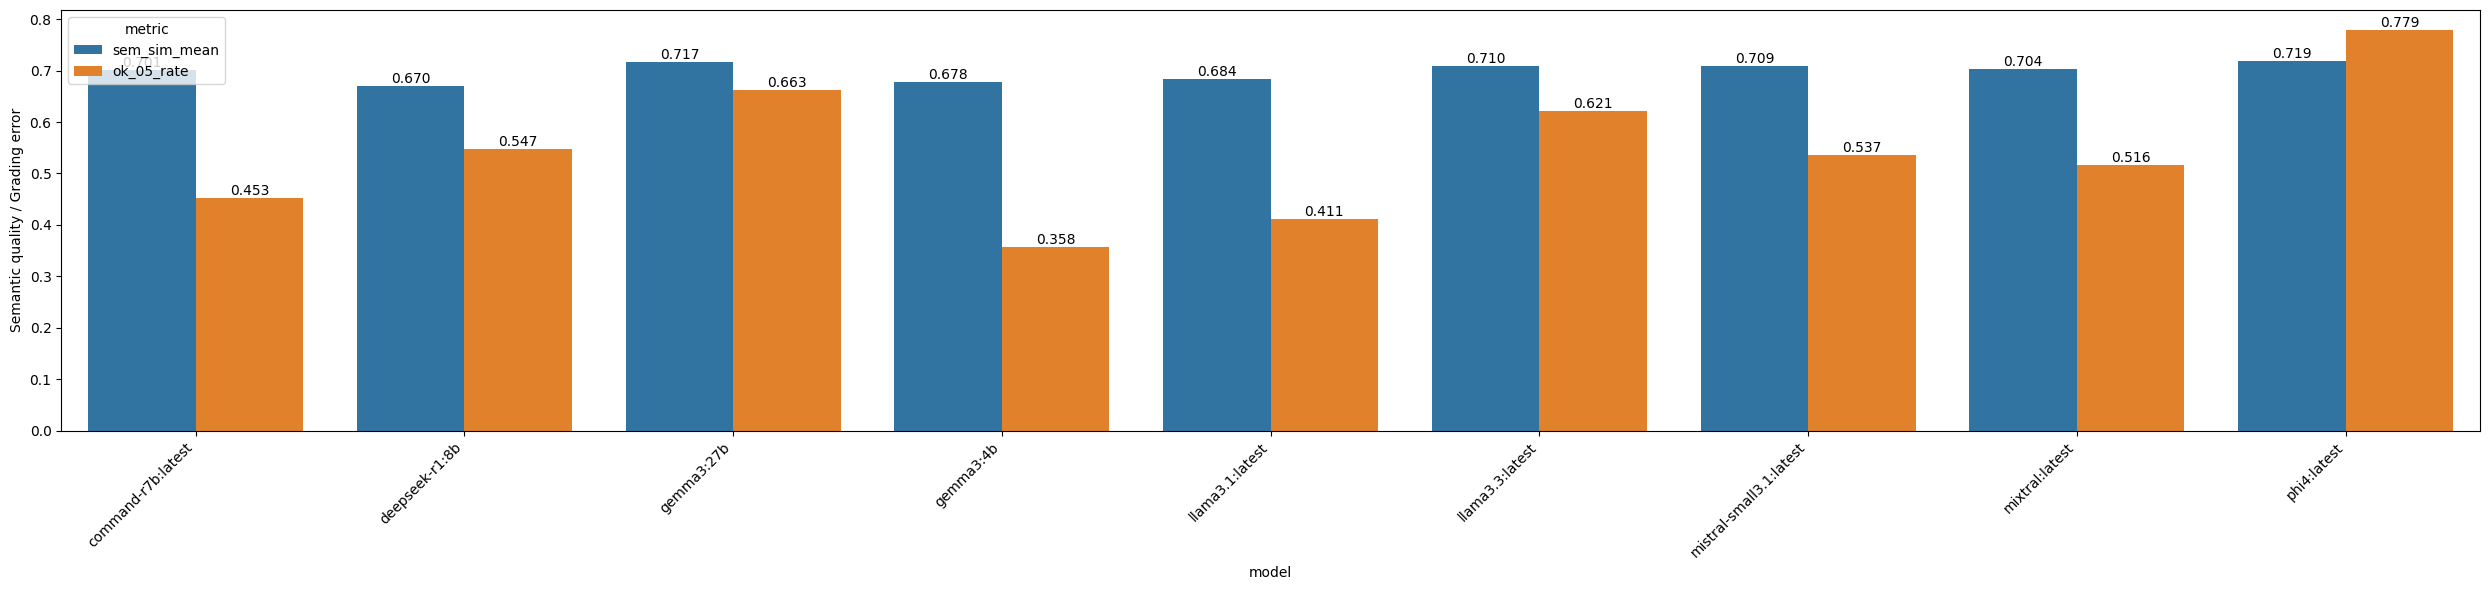

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df["error_perf_neg"] = -final_df["error_perf"]

df_plot = grade_quality.reset_index().melt(
    id_vars="model",
    value_vars=["sem_sim_mean", "ok_05_rate"],
    var_name="metric",
    value_name="value"
)
plt.figure(figsize=(25,6))
ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")
ax.set_ylabel("Semantic quality / Grading error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()   
plt.show()

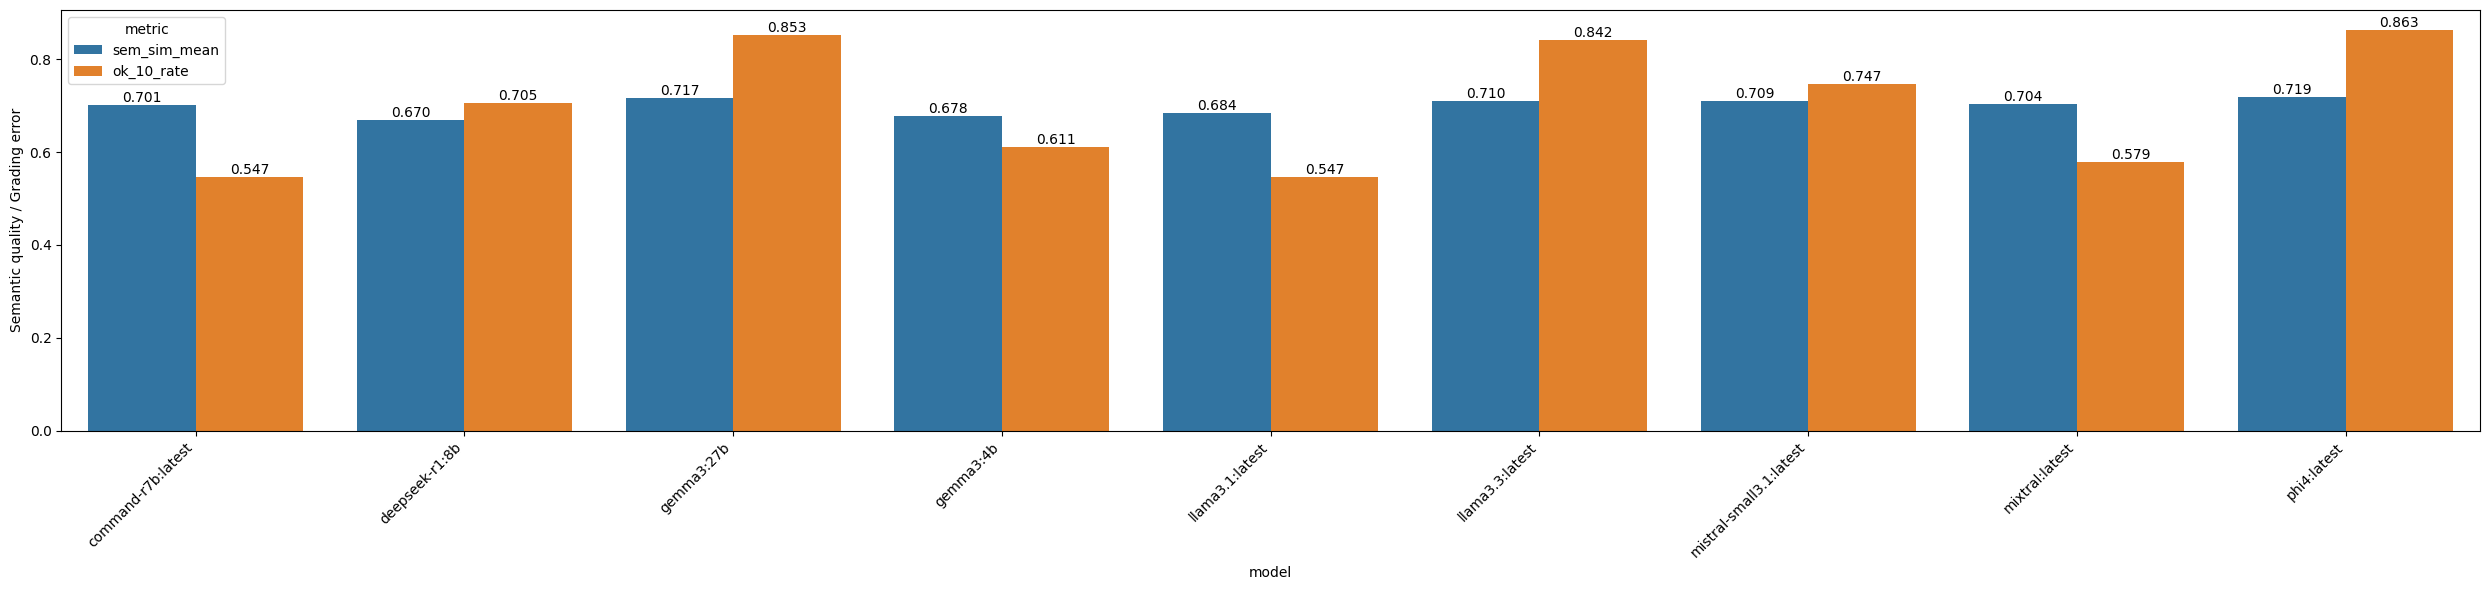

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df["error_perf_neg"] = -final_df["error_perf"]

df_plot = grade_quality.reset_index().melt(
    id_vars="model",
    value_vars=["sem_sim_mean", "ok_10_rate"],
    var_name="metric",
    value_name="value"
)
plt.figure(figsize=(25,6))
ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")
ax.set_ylabel("Semantic quality / Grading error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()   
plt.show()

In [36]:
agg = final_df.groupby("model")[[
    "chrf", "error_content_f1", "bertscore_f1",
    # falls du die auch schon hast:
    "abs_error", "error_perf"
]].mean().sort_values("bertscore_f1", ascending=False)

agg

,chrf,error_content_f1,bertscore_f1,abs_error,error_perf
model,,,,,
mixtral:latest,0.379872,0.159657,0.313152,1.200000,0.770439
mistral-small3.1:latest,0.393622,0.155326,0.310197,0.884211,0.829010
llama3.3:latest,0.396489,0.159969,0.306240,0.705263,0.864474
command-r7b:latest,0.346243,0.154184,0.302058,1.410526,0.730509
phi4:latest,0.401675,0.170372,0.291587,0.578947,0.886930
gemma3:27b,0.375477,0.172997,0.284869,0.702105,0.862794
llama3.1:latest,0.331126,0.138426,0.278453,1.305263,0.745689
deepseek-r1:8b,0.335224,0.136896,0.237128,0.923158,0.820807
gemma3:4b,0.337321,0.113694,0.235882,1.278947,0.751754


In [37]:
final_df["bertscore_f1"]

0      0.327383
1      0.123108
2      0.148940
3      0.132995
4      0.275093
         ...   
850    0.399689
851    0.526652
852    0.320391
853    0.235318
854    0.407459
Name: bertscore_f1, Length: 855, dtype: float32

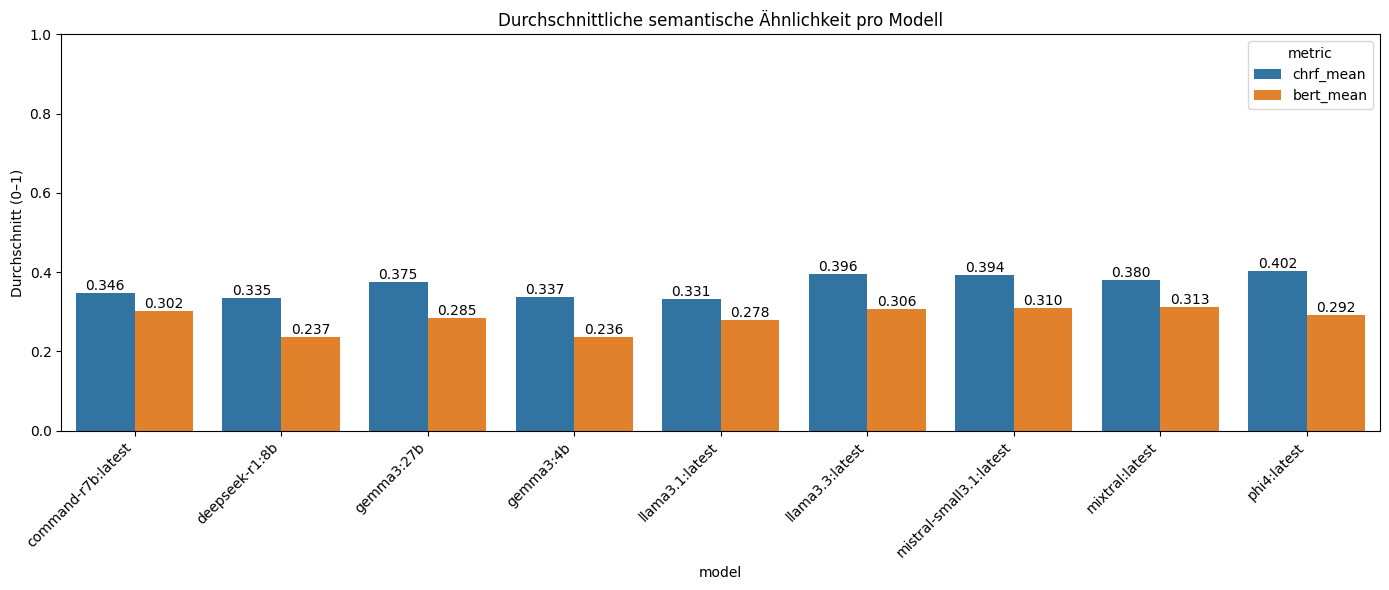

In [38]:
import numpy as np

summary = final_df.groupby("model").agg(
    chrf_mean=("chrf", "mean"),
    chrf_std=("chrf", "std"),
    bert_mean=("bertscore_f1", "mean"),
    bert_std=("bertscore_f1", "std"),
).reset_index()

# Long-Format für Plot
sum_long = summary.melt(id_vars="model",
                        value_vars=["chrf_mean", "bert_mean"],
                        var_name="metric", value_name="mean")

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=sum_long, x="model", y="mean", hue="metric")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Durchschnitt (0–1)")
plt.title("Durchschnittliche semantische Ähnlichkeit pro Modell")
plt.tight_layout()
plt.show()
